# **CSL2050: Pattern Recognition and Machine Learning**
## **Course Project: Hand-drawn Sketch Recognition**

### **Step 1:** Importing the dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

# Define paths
zip_path = "/content/drive/My Drive/Dataset_PNG.zip"  # Space in "My Drive" is fine here
extract_path = "/content/Dataset_PNG"

# Create extract folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify extraction
print(os.listdir(extract_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['sketches_png']


In [3]:
!apt-get install unzip -y
!unzip "/content/drive/My Drive/Dataset_PNG.zip" -d /content/Dataset_PNG

Streaming output truncated to the last 5000 lines.
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15001.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15002.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15003.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15004.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15005.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15006.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15007.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15008.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15009.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15010.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15011.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15012.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15013.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15014.png

In [4]:
dataset_path = "/content/Dataset_PNG/sketches_png/png"

# Check the extracted dataset folder
print(os.listdir(dataset_path))  # Should show category folders like 'zebra', 'cat', etc.

# Check some images inside a category
sample_category = os.path.join(dataset_path, "zebra")  # Change to any category name
print(os.listdir(sample_category)[:5])  # List first 5 images

['feather', 'revolver', 'cannon', 'megaphone', 'cake', 'bridge', 'pumpkin', 'microphone', 'castle', 'couch', 'floor lamp', 'lightbulb', 'speed-boat', 'crab', 'church', 'ear', 'mailbox', 'helicopter', 'brain', 'computer monitor', 'cup', 'crown', 'stapler', 'grenade', 'tiger', 'pen', 'barn', 'horse', 'banana', 'standing bird', 'wheel', 'bowl', 'alarm clock', 'tablelamp', 'scissors', 'rifle', 'knife', 'human-skeleton', 'cow', 'walkie talkie', 'door handle', 'camel', 'parking meter', 'monkey', 'dragon', 'house', 'sailboat', 'pretzel', 'screwdriver', 'helmet', 'pig', 'ship', 'lobster', 'envelope', 'piano', 'book', 'purse', 'hourglass', 'snowman', 'apple', 'hammer', 'shovel', 'radio', 'mosquito', 'swan', 'wineglass', 'windmill', 'boomerang', 'snail', 'mermaid', 'skateboard', 'beer-mug', 'binoculars', 'bookshelf', 'seagull', 'space shuttle', 'canoe', 'rainbow', 'spoon', 'hand', 'skyscraper', 'bear (animal)', 'potted plant', 'satellite dish', 'cactus', 'traffic light', 't-shirt', 'telephone', 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.7/291.7 MB 3.6 MB/s eta 0:00:00


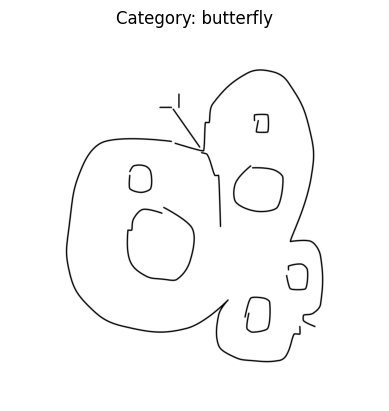

In [5]:
!pip install opencv-python
!pip install tensorflow
!pip install xgboost
import cv2
import matplotlib.pyplot as plt
import random

# Pick a random category
categories = os.listdir(dataset_path)
random_category = random.choice(categories)

# Pick a random image from the category
image_folder = os.path.join(dataset_path, random_category)
image_name = random.choice(os.listdir(image_folder))
image_path = os.path.join(image_folder, image_name)

# Load and display the image
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
plt.imshow(image, cmap='gray')
plt.title(f"Category: {random_category}")
plt.axis("off")
plt.show()

In [6]:
import numpy as np
import os
import cv2
from tqdm import tqdm
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import xgboost as xgb
import torch

# Device check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

# Load ResNet50 base model
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
base_model.trainable = False

# CNN feature extraction
def extract_cnn_features_batch(images):
    images_preprocessed = preprocess_input(images)
    features = base_model.predict(images_preprocessed, verbose=0)
    return features

# Load dataset and extract CNN features
def load_cnn_features(dataset_path, max_samples=100, batch_size=32):
    categories = os.listdir(dataset_path)
    X, y = [], []

    for category in tqdm(categories, desc="Loading categories"):
        cat_path = os.path.join(dataset_path, category)
        samples = 0
        batch_images = []

        for img_name in os.listdir(cat_path)[:max_samples]:
            img_path = os.path.join(cat_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            img_resized = cv2.resize(img_rgb, (224, 224))
            batch_images.append(img_resized)
            samples += 1

            if len(batch_images) == batch_size or (samples == max_samples and batch_images):
                batch_array = np.array(batch_images)
                features = extract_cnn_features_batch(batch_array)
                X.extend(features)
                y.extend([category] * len(features))
                batch_images = []

            if samples >= max_samples:
                break

        if batch_images:
            batch_array = np.array(batch_images)
            features = extract_cnn_features_batch(batch_array)
            X.extend(features)
            y.extend([category] * len(features))

    return np.array(X), np.array(y)

# Load data
dataset_path = "/content/Dataset_PNG/sketches_png/png"
X, y = load_cnn_features(dataset_path, max_samples=100, batch_size=32)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define individual models
gnb = GaussianNB()
xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y_encoded)),
    max_depth=4,
    learning_rate=0.05,
    n_estimators=30,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    use_label_encoder=False,
    verbosity=0
)

# Create ensemble using soft voting
ensemble = VotingClassifier(
    estimators=[
        ('naive_bayes', gnb),
        ('xgboost', xgb_clf)
    ],
    voting='soft'  # Use 'soft' for probabilities
)

# Train ensemble
ensemble.fit(X_train_scaled, y_train)

# Predict using ensemble
y_pred = ensemble.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nCNN + Naive Bayes + XGBoost (Ensemble) Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))


Using cpu device
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Loading categories: 100%|██████████| 250/250 [57:57<00:00, 13.91s/it]



CNN + Naive Bayes + XGBoost (Ensemble) Accuracy: 0.3630

Classification Report:
                    precision    recall  f1-score   support

          airplane       0.43      0.19      0.26        16
       alarm clock       0.69      0.56      0.62        16
             angel       0.07      0.12      0.09        16
               ant       0.18      0.19      0.18        16
             apple       0.77      0.62      0.69        16
               arm       0.10      0.06      0.08        16
          armchair       0.20      0.25      0.22        16
           ashtray       0.23      0.19      0.21        16
               axe       0.46      0.38      0.41        16
          backpack       0.33      0.50      0.40        16
            banana       0.23      0.19      0.21        16
              barn       0.27      0.19      0.22        16
      baseball bat       0.38      0.38      0.38        16
            basket       0.58      0.44      0.50        16
           bathtub